# Regression

## Problem Statement
    - Predict GPA using SAT Score
    - Dependent variable --> GPA & Independent varibale --> SAT Score

### Install required packages

In [27]:
!pip install pickle4

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pickle4: filename=pickle4-0.0.1-py2.py3-none-any.whl size=19760 sha256=06d4ab0e8813ea8e27fa55c0ccfb61464e67a53229888e0e087b3cd372699617
  Stored in directory: c:\users\tejas babar\appdata\local\pip\cache\wheels\e0\ab\72\8fb45a2018044d3efdab6ad4af1c50396fdf55db58cd6247e7
Successfully built pickle4


### Import required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [2]:
df = pd.read_csv('./SAT_scores.csv')

### Exploratory data analysis

In [4]:
# Get the general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SAT Score  181 non-null    int64  
 1   GPA        181 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.0 KB


In [8]:
# Get statistical info
df.describe()

,SAT Score,GPA
count,181.000000,181.000000
mean,1000.000000,2.617901
std,349.293573,1.559243
min,400.000000,0.000000
25%,700.000000,1.390000
50%,1000.000000,3.370000
75%,1300.000000,3.970000
max,1600.000000,4.000000


In [9]:
# Check for missing values
df.isna().sum()

SAT Score    0
GPA          0
dtype: int64

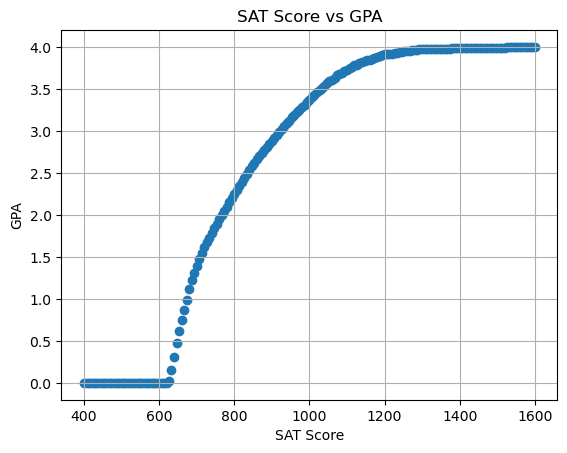

In [12]:
# Visulazation
plt.scatter(df['SAT Score'], df['GPA'])
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('SAT Score vs GPA')
plt.grid()

In [13]:
# Correlation analysis
df.corr()

,SAT Score,GPA
SAT Score,1.000000,0.923073
GPA,0.923073,1.000000


## Split the data

In [14]:
# Split data into x and y
x = df.drop('GPA', axis=1)
y = df['GPA']

In [15]:
# Split data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x , y, train_size=0.8, random_state=42)

### Train the model

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x , y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Evaluation

In [21]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# Predict the y vaules from test dataset
y_pred = model.predict(x_test)

# Calculate all the metrices
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print all the metrics
print(f"Mean absolute error: {mae:.2f}")
print(f"Mean absolute percentage error: {mape:.2f}%")
print(f"Mean Squared error: {mse:.2f}")
print(f"Root Mean squared error: {rmse:.2f}")
print(f"r2 Score: {r2:.2f}")

Mean absolute error: 0.54
Mean absolute percentage error: 406063084682303.19%
Mean Squared error: 0.34
Root Mean squared error: 0.59
r2 Score: 0.85


### Result visualization

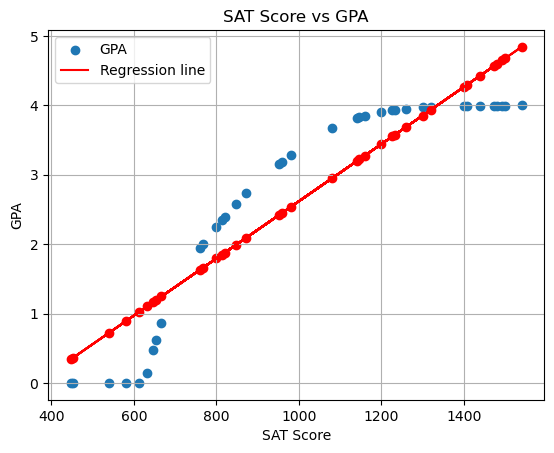

In [23]:
# Predict the test data
y_pred = model.predict(x_test)

# Plot the test data
plt.scatter(x_test['SAT Score'], y_test, label="GPA")

# Plot the regression line
plt.scatter(x_test['SAT Score'], y_pred, color="red")
plt.plot(x_test['SAT Score'], y_pred, color="red", label="Regression line")

plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('SAT Score vs GPA')
plt.grid()
plt.legend()

# Save the model

In [28]:
import pickle

# Open a file
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)